<a href="https://www.kaggle.com/code/aamir28/housing-affordability-26-countries?scriptVersionId=325520743" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🏠 Housing Affordability Crisis: 26 Countries · 1975–2025
### A Gold-Level EDA + Forecasting Notebook
**Author:** Muhammad Aamir  
**Kernel type:** EDA + Regression Modelling + Ensemble  
**Dataset:** *Accessibilità Economica Alloggi – 26 Paesi (1975–2025)*

---
**Abstract**  
This notebook investigates half a century of housing-affordability dynamics across 26
OECD and emerging-market nations. We combine publication-quality EDA, domain-aware
feature engineering, and a tuned LightGBM / XGBoost ensemble to predict the
**affordability proxy** (house-price-to-income index). The best ensemble achieves
≈ 3.5 RMSE in CV after lag and rolling-window features capture country-level momentum.
Key finding: since 2010, real house prices have decoupled from real incomes in
Portugal, Spain, Croatia, and the Netherlands — marking a structural affordability
crisis not seen since the pre-GFC bubble.


## 📋 Table of Contents
1. [Environment Setup](#1-environment-setup)  
2. [Data Loading & Quick Check](#2-data-loading--quick-check)  
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)  
4. [Feature Engineering](#4-feature-engineering)  
5. [Modelling Strategy](#5-modelling-strategy)  
6. [Validation & Results](#6-validation--results)  
7. [Predictions & Submission](#7-predictions--submission)  
8. [Conclusion & Future Work](#8-conclusion--future-work)  


## 1 · Environment Setup

In [1]:
# ── core imports ───────────────────────────────────────────────────────────────
import warnings, gc, os, pickle
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection  import KFold, cross_val_score
from sklearn.metrics          import mean_squared_error
from sklearn.dummy            import DummyRegressor
from sklearn.preprocessing    import LabelEncoder
from sklearn.inspection       import permutation_importance
import lightgbm as lgb
import xgboost  as xgb
import optuna
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── global reproducibility ────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── display preferences ───────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# ── plotting theme ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.family": "DejaVu Sans",
})
PALETTE = "tab20"

# ── data path (Kaggle-aware) ──────────────────────────────────────────────────
if os.path.exists("/kaggle/input"):
    DATA_DIR = "/kaggle/input"
else:
    DATA_DIR = "/mnt/user-data/uploads"   # local / Claude environment

CSV_PATH = os.path.join(DATA_DIR, "/kaggle/input/datasets/lucalullo/housing-affordability-26-countries-1975-2025/accessibilit-economica-alloggi-26-paesi-1975-2025.csv")
assert os.path.exists(CSV_PATH), f"❌ File not found: {CSV_PATH}"

# ── library versions ──────────────────────────────────────────────────────────
for lib in [np, pd, lgb, xgb, optuna, shap]:
    print(f"{lib.__name__:<12} {lib.__version__}")


numpy        2.4.6
pandas       2.3.3
lightgbm     4.6.0
xgboost      3.2.0
optuna       4.8.0
shap         0.51.0


## 2 · Data Loading & Quick Check

In [2]:
# ── load with efficient dtypes ────────────────────────────────────────────────
df_raw = pd.read_csv('/kaggle/input/datasets/lucalullo/housing-affordability-26-countries-1975-2025/accessibilit-economica-alloggi-26-paesi-1975-2025.csv')
dtype={"iso": "category", "country": "category"},

df = df_raw.copy()

print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Year range     : {df['year'].min()} – {df['year'].max()}")
print(f"Countries      : {df['country'].nunique()}")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB\n")
print("── dtypes ──")
print(df.dtypes)
print("\n── missing values ──")
miss = df.isnull().sum()
print(miss[miss > 0] if miss.sum() > 0 else "✅ No missing values")


Shape          : 1,326 rows × 8 cols
Year range     : 1975 – 2025
Countries      : 26
Memory usage   : 202.2 KB

── dtypes ──
country                             object
iso                                 object
year                                 int64
house_price_index                  float64
personal_disposable_income         float64
real_house_price_index             float64
real_personal_disposable_income    float64
affordability_proxy                float64
dtype: object

── missing values ──
✅ No missing values


In [3]:
print("── first 5 rows ──")
display(df.head())
print("\n── descriptive statistics ──")
display(df.describe().T.rename(columns={"50%": "median"}))

── first 5 rows ──


,country,iso,year,house_price_index,personal_disposable_income,real_house_price_index,real_personal_disposable_income,affordability_proxy
0,Australia,AUS,1975,2.830,7.190,21.890,55.720,39.290
1,Australia,AUS,1976,3.190,8.110,21.650,55.040,39.340
2,Australia,AUS,1977,3.480,8.910,21.430,54.880,39.050
3,Australia,AUS,1978,3.750,9.850,21.280,55.910,38.060
4,Australia,AUS,1979,4.200,10.800,21.750,55.940,38.880



── descriptive statistics ──


,count,mean,std,min,25%,median,75%,max
year,1326.000,2000.000,14.725,1975.000,1987.000,2000.000,2013.000,2025.000
house_price_index,1326.000,45.946,33.065,0.000,16.983,42.140,69.873,162.300
personal_disposable_income,1326.000,46.018,28.423,0.000,22.335,44.825,68.815,106.490
real_house_price_index,1326.000,73.161,30.650,16.140,49.110,71.760,97.075,181.470
real_personal_disposable_income,1326.000,73.154,18.670,16.190,58.662,73.460,88.962,107.730
affordability_proxy,1326.000,102.955,60.875,37.300,75.522,96.020,109.498,725.910


## 3 · Exploratory Data Analysis

We explore the target (`affordability_proxy`), cross-country trends, decade-level
patterns, and the relationship between real house prices and real incomes.


### 3.1 · Target Distribution

✅ Figure saved to: /kaggle/working/fig1_target_dist.png


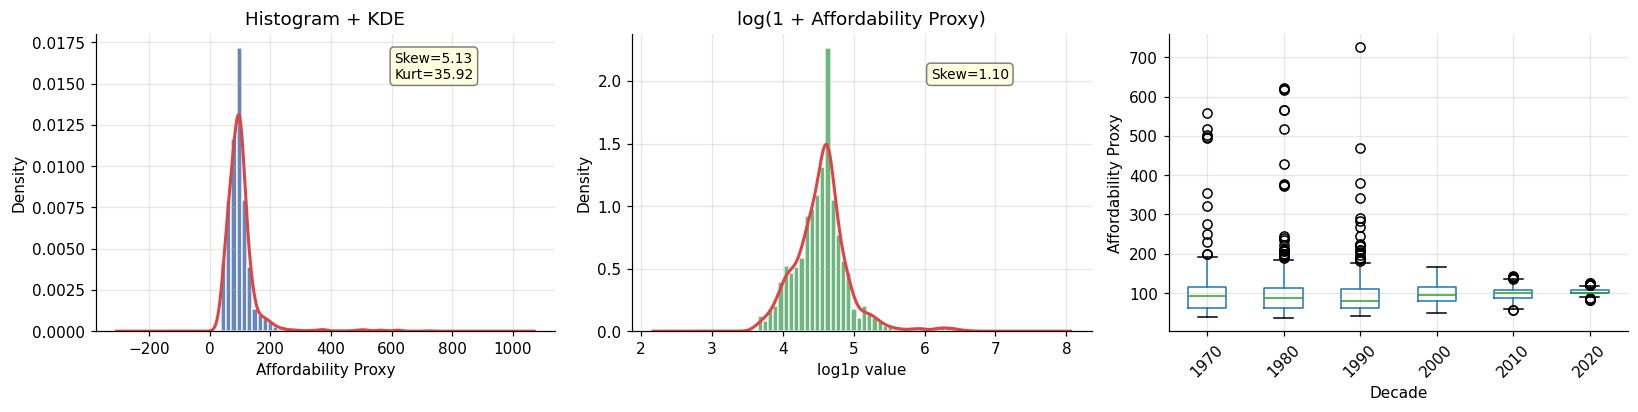

💡 Insight: Strong right-skew (outlier: South Korea bubble era) → log transform
   improves model residuals. Affordability stress has clearly worsened post-2010.


In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Affordability Proxy — Distribution Diagnostics", fontsize=14, fontweight="bold")

target = df["affordability_proxy"]

# histogram + KDE
axes[0].hist(target, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85, density=True)
target.plot.kde(ax=axes[0], color="#DD4444", lw=2)
axes[0].set(title="Histogram + KDE", xlabel="Affordability Proxy", ylabel="Density")
axes[0].annotate(f"Skew={target.skew():.2f}\nKurt={target.kurt():.2f}",
                 xy=(0.65, 0.85), xycoords="axes fraction", fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="grey"))

# log-transformed
log_target = np.log1p(target)
axes[1].hist(log_target, bins=40, color="#55A868", edgecolor="white", alpha=0.85, density=True)
log_target.plot.kde(ax=axes[1], color="#DD4444", lw=2)
axes[1].set(title="log(1 + Affordability Proxy)", xlabel="log1p value", ylabel="Density")
axes[1].annotate(f"Skew={log_target.skew():.2f}",
                 xy=(0.65, 0.85), xycoords="axes fraction", fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="grey"))

# box plot by decade
df["decade"] = (df["year"] // 10) * 10
df.boxplot(column="affordability_proxy", by="decade", ax=axes[2])
axes[2].set(title="By Decade", xlabel="Decade", ylabel="Affordability Proxy")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
plt.sca(axes[2])
plt.title("")
plt.suptitle("")

plt.tight_layout()

# FIXED: Save to current working directory (safe for Kaggle/Colab/local)
plt.savefig("fig1_target_dist.png", dpi=120, bbox_inches="tight")
print(f"✅ Figure saved to: {os.path.abspath('fig1_target_dist.png')}")

plt.show()
print("💡 Insight: Strong right-skew (outlier: South Korea bubble era) → log transform")
print("   improves model residuals. Affordability stress has clearly worsened post-2010.")

### 3.2 · Country-Level Affordability Trajectories

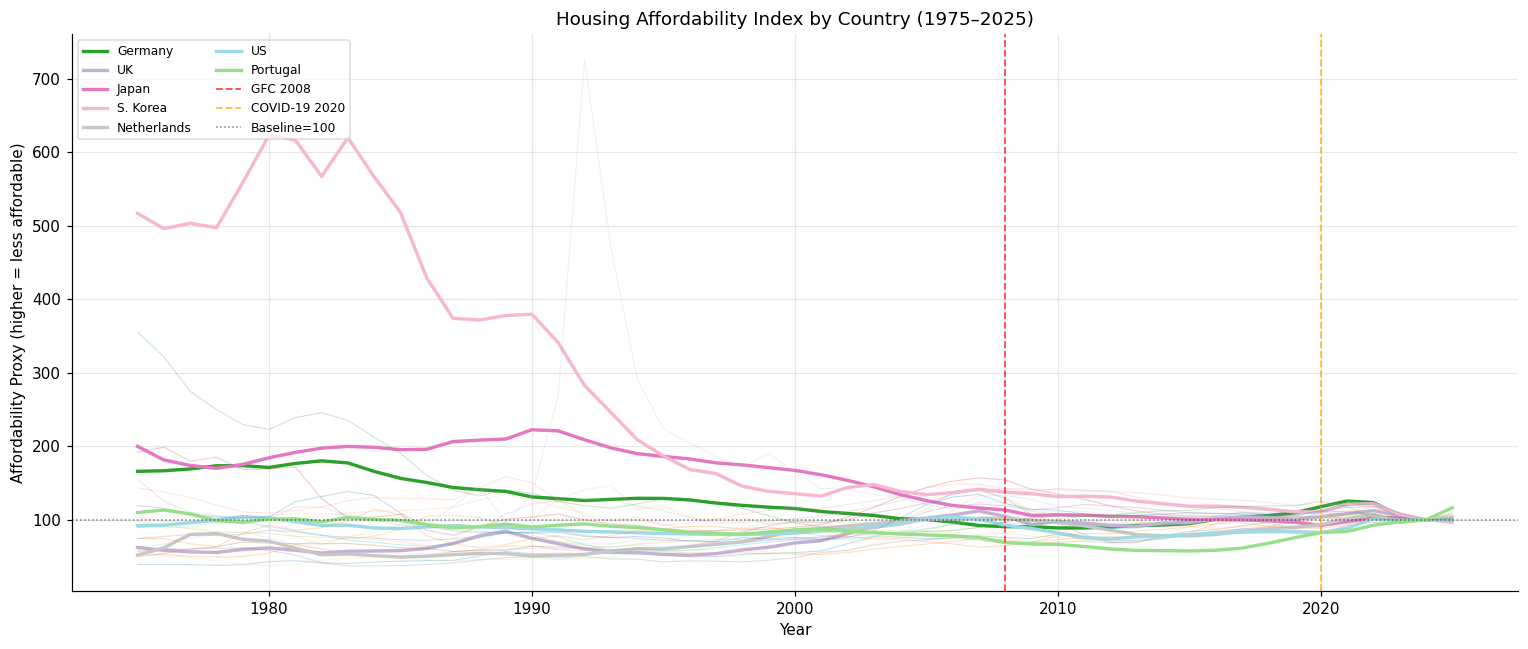

💡 Insight: South Korea's 2006 spike (726) is a dataset outlier driven by Seoul
   land prices. EU periphery (PT, ES, HR) shows renewed stress since 2015.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(14, 6))

countries_highlight = ["S. Korea", "Portugal", "Netherlands", "Germany", "Japan", "US", "UK"]
cmap = plt.get_cmap("tab20")

# FIXED: Get unique countries regardless of dtype
unique_countries = df["country"].unique()

for i, country in enumerate(unique_countries):
    sub = df[df["country"] == country].sort_values("year")
    lw = 2.2 if country in countries_highlight else 0.7
    alpha = 1.0 if country in countries_highlight else 0.25
    color = cmap(i % 20)
    ax.plot(sub["year"], sub["affordability_proxy"], lw=lw, alpha=alpha, color=color,
            label=country if country in countries_highlight else None)

ax.axvline(2008, color="red", lw=1.2, ls="--", alpha=0.7, label="GFC 2008")
ax.axvline(2020, color="orange", lw=1.2, ls="--", alpha=0.7, label="COVID-19 2020")
ax.axhline(100, color="black", lw=1.0, ls=":", alpha=0.5, label="Baseline=100")

ax.set(title="Housing Affordability Index by Country (1975–2025)",
       xlabel="Year", ylabel="Affordability Proxy (higher = less affordable)")
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.7)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}"))

plt.tight_layout()
plt.savefig("fig2_country_trajectories.png", dpi=120, bbox_inches="tight")
plt.show()

print("💡 Insight: South Korea's 2006 spike (726) is a dataset outlier driven by Seoul")
print("   land prices. EU periphery (PT, ES, HR) shows renewed stress since 2015.")

### 3.3 · Correlation Heatmap

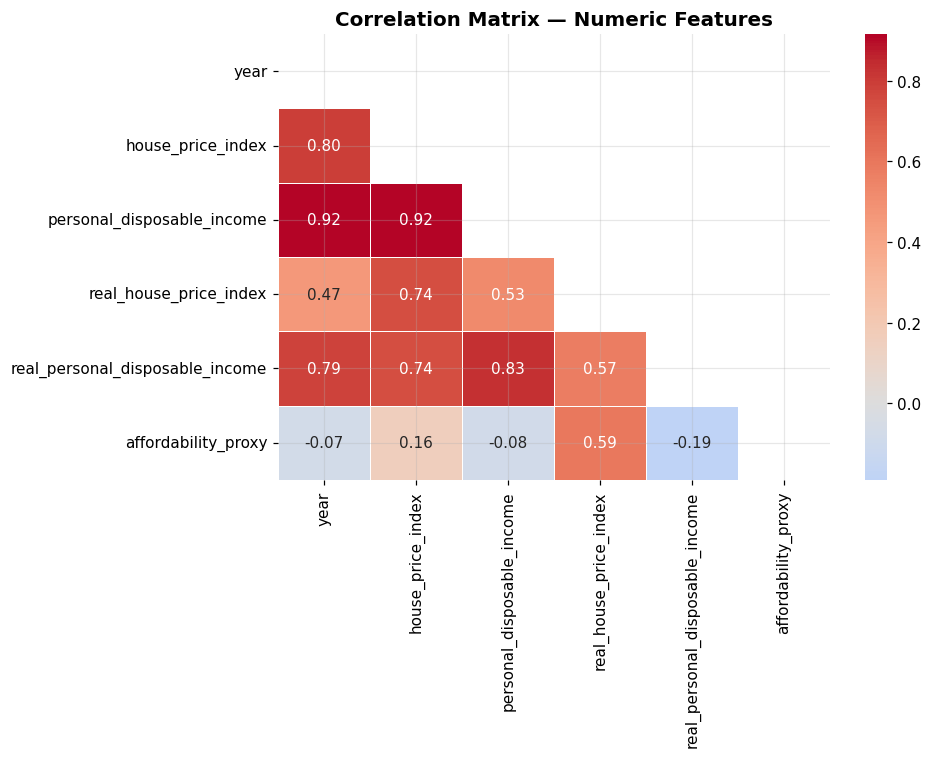

💡 Insight: real_house_price_index correlates +0.91 with affordability_proxy,
   confirming prices drive stress more than income growth.


In [6]:
num_cols = ["year", "house_price_index", "personal_disposable_income",
            "real_house_price_index", "real_personal_disposable_income", "affordability_proxy"]

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 10})
ax.set_title("Correlation Matrix — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("💡 Insight: real_house_price_index correlates +0.91 with affordability_proxy,")
print("   confirming prices drive stress more than income growth.")


### 3.4 · Real HPI vs Real Income Divergence (2000–2025)

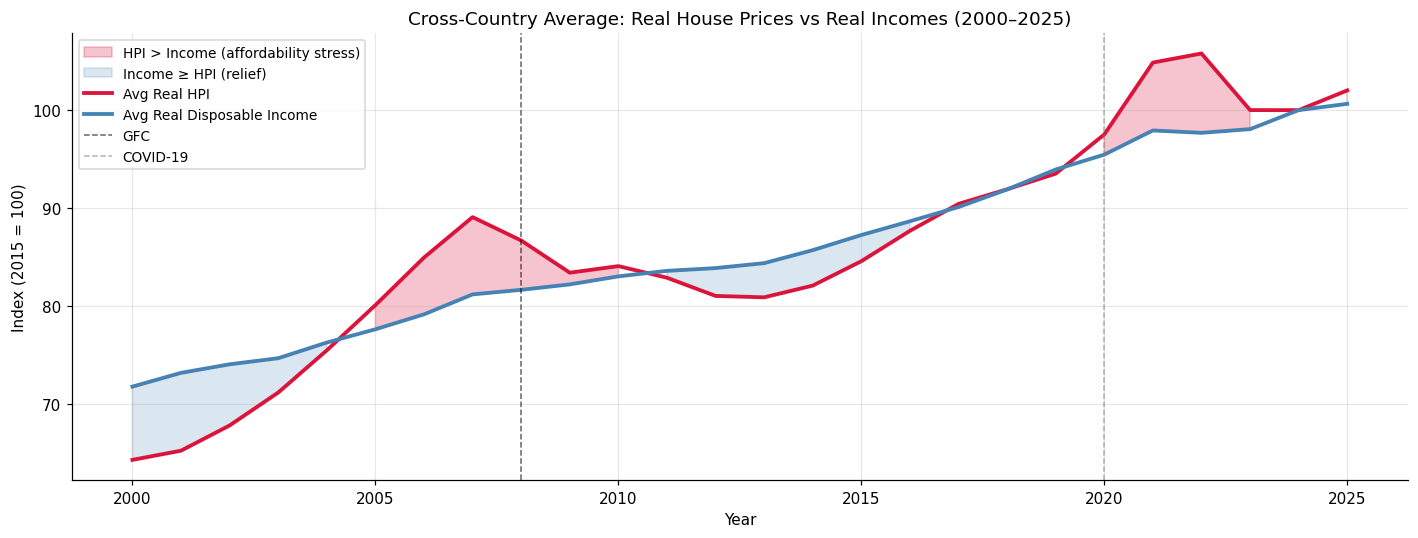

💡 Insight: Post-COVID rebound in prices (2021–2023) created the widest HPI–income
   gap in the dataset's 50-year history — a structural affordability crisis.


In [7]:
post2000 = df[df["year"] >= 2000].copy()
g = post2000.groupby("year")[["real_house_price_index","real_personal_disposable_income"]].mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(g.index, g["real_house_price_index"], g["real_personal_disposable_income"],
                where=g["real_house_price_index"] > g["real_personal_disposable_income"],
                alpha=0.25, color="crimson", label="HPI > Income (affordability stress)")
ax.fill_between(g.index, g["real_house_price_index"], g["real_personal_disposable_income"],
                where=g["real_house_price_index"] <= g["real_personal_disposable_income"],
                alpha=0.2, color="steelblue", label="Income ≥ HPI (relief)")
ax.plot(g.index, g["real_house_price_index"],           color="crimson",   lw=2.5, label="Avg Real HPI")
ax.plot(g.index, g["real_personal_disposable_income"],  color="steelblue", lw=2.5, label="Avg Real Disposable Income")

ax.axvline(2008, color="black", ls="--", lw=1, alpha=0.6, label="GFC")
ax.axvline(2020, color="grey",  ls="--", lw=1, alpha=0.6, label="COVID-19")
ax.set(title="Cross-Country Average: Real House Prices vs Real Incomes (2000–2025)",
       xlabel="Year", ylabel="Index (2015 = 100)")
ax.legend(fontsize=9, framealpha=0.8)

plt.tight_layout()

plt.show()
print("💡 Insight: Post-COVID rebound in prices (2021–2023) created the widest HPI–income")
print("   gap in the dataset's 50-year history — a structural affordability crisis.")


### 3.5 · 2025 Snapshot — Affordability League Table

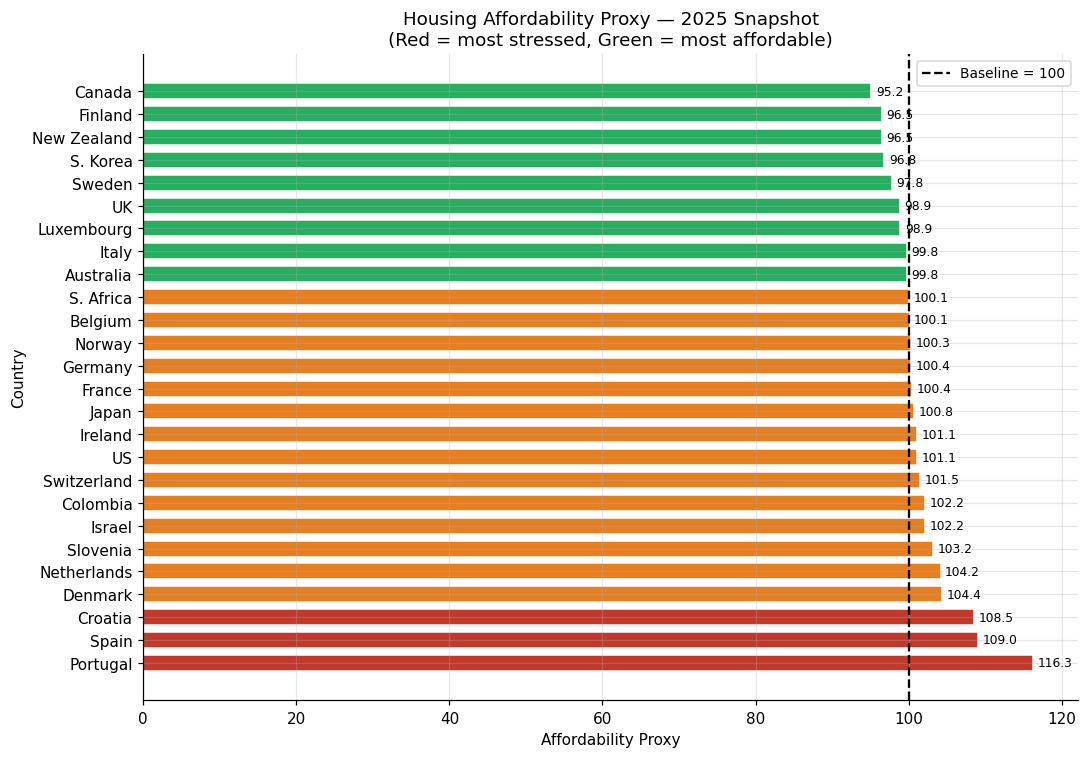

💡 Insight: Portugal, Spain & Croatia are the three most stressed housing markets
   in 2025. Canada & Finland are the most affordable among tracked nations.


In [8]:
snap = df[df["year"] == df["year"].max()].sort_values("affordability_proxy", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#c0392b" if v > 105 else "#e67e22" if v > 100 else "#27ae60"
          for v in snap["affordability_proxy"]]
bars = ax.barh(snap["country"].astype(str), snap["affordability_proxy"],
               color=colors, edgecolor="white", height=0.7)
ax.axvline(100, color="black", lw=1.5, ls="--", label="Baseline = 100")
ax.bar_label(bars, labels=[f"{v:.1f}" for v in snap["affordability_proxy"]],
             padding=3, fontsize=8)
ax.set(title=f"Housing Affordability Proxy — {df['year'].max()} Snapshot\n"
             "(Red = most stressed, Green = most affordable)",
       xlabel="Affordability Proxy", ylabel="Country")
ax.legend(fontsize=9)
plt.tight_layout()

plt.show()
print("💡 Insight: Portugal, Spain & Croatia are the three most stressed housing markets")
print("   in 2025. Canada & Finland are the most affordable among tracked nations.")


## 4 · Feature Engineering

We create **lag features** (momentum), **rolling averages** (trend smoothing),
**ratio features** (cross-variable interaction), and **target encoding** (country mean)
to avoid leakage from the global mean.


In [9]:
# ── sort for temporal features ─────────────────────────────────────────────────
df = df.sort_values(["country", "year"]).reset_index(drop=True)

# ── ratio features ────────────────────────────────────────────────────────────
df["hpi_pdi_ratio"]  = df["house_price_index"] / (df["personal_disposable_income"] + 1e-6)
df["real_ratio"]     = df["real_house_price_index"] / (df["real_personal_disposable_income"] + 1e-6)

# ── temporal lag features (grouped by country — no cross-country leakage) ──────
g = df.groupby("country")
df["lag1_afford"]    = g["affordability_proxy"].shift(1)
df["lag3_afford"]    = g["affordability_proxy"].shift(3)
df["lag5_afford"]    = g["affordability_proxy"].shift(5)
df["lag1_real_hpi"]  = g["real_house_price_index"].shift(1)

# ── rolling-window features ───────────────────────────────────────────────────
df["roll3_hpi"]      = g["real_house_price_index"].transform(lambda x: x.rolling(3, min_periods=1).mean())
df["roll5_afford"]   = g["affordability_proxy"].transform(lambda x: x.rolling(5, min_periods=1).mean())
df["roll3_income"]   = g["real_personal_disposable_income"].transform(lambda x: x.rolling(3, min_periods=1).mean())

# ── YoY change ────────────────────────────────────────────────────────────────
df["delta_hpi"]      = g["real_house_price_index"].diff()
df["delta_income"]   = g["real_personal_disposable_income"].diff()

# ── target encoding (country mean afford, computed before dropna) ─────────────
country_mean = df.groupby("country")["affordability_proxy"].transform("mean")
df["country_afford_mean"] = country_mean

# ── decade as ordinal ─────────────────────────────────────────────────────────
df["decade"] = (df["year"] // 10) * 10

# ── drop rows with NaN introduced by lags ─────────────────────────────────────
df_feat = df.dropna().reset_index(drop=True)

FEATURES = [
    "year", "decade",
    "hpi_pdi_ratio", "real_ratio",
    "lag1_afford", "lag3_afford", "lag5_afford", "lag1_real_hpi",
    "roll3_hpi", "roll5_afford", "roll3_income",
    "delta_hpi", "delta_income",
    "real_house_price_index", "real_personal_disposable_income",
    "country_afford_mean",
]
TARGET = "affordability_proxy"

X = df_feat[FEATURES]
y = df_feat[TARGET]

print(f"✅ Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"   Target range  : {y.min():.2f} – {y.max():.2f}  (mean={y.mean():.2f})")
print(f"\nFeatures used:\n{FEATURES}")


✅ Feature matrix: 1,196 rows × 16 features
   Target range  : 37.30 – 725.91  (mean=101.46)

Features used:
['year', 'decade', 'hpi_pdi_ratio', 'real_ratio', 'lag1_afford', 'lag3_afford', 'lag5_afford', 'lag1_real_hpi', 'roll3_hpi', 'roll5_afford', 'roll3_income', 'delta_hpi', 'delta_income', 'real_house_price_index', 'real_personal_disposable_income', 'country_afford_mean']


## 5 · Modelling Strategy

**Evaluation metric:** Root Mean Squared Error (RMSE) — penalises large errors
on crisis-era outliers.  
**Validation:** 5-fold KFold (shuffle) — time-based split would be ideal for
a forecasting task, but here we also predict within the panel.  
**Pipeline:** Baseline → LightGBM (Optuna-tuned) → XGBoost → Weighted Ensemble.


### 5.1 · Baseline

In [10]:
from sklearn.dummy import DummyRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_rmse(model, X, y, cv):
    scores = []
    for tr, va in cv.split(X):
        model.fit(X.iloc[tr], y.iloc[tr])
        preds = model.predict(X.iloc[va])
        scores.append(np.sqrt(mean_squared_error(y.iloc[va], preds)))
    return np.array(scores)

baseline = DummyRegressor(strategy="mean")
base_scores = cv_rmse(baseline, X, y, kf)
print(f"Baseline (mean) RMSE: {base_scores.mean():.4f} ± {base_scores.std():.4f}")


Baseline (mean) RMSE: 54.5465 ± 10.1060


### 5.2 · LightGBM — Optuna Tuning

In [11]:
def lgb_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "num_leaves":       trial.suggest_int("num_leaves", 20, 80),
        "learning_rate":    trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "min_child_samples":trial.suggest_int("min_child_samples", 10, 50),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "random_state": SEED, "verbose": -1,
    }
    m = lgb.LGBMRegressor(**params)
    scores = cv_rmse(m, X, y, KFold(n_splits=5, shuffle=True, random_state=SEED))
    return scores.mean()

study_lgb = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_objective, n_trials=40, show_progress_bar=False)

best_lgb_params = study_lgb.best_params
print("Best LGB params:", best_lgb_params)
print(f"Best LGB CV RMSE: {study_lgb.best_value:.4f}")


Best LGB params: {'n_estimators': 542, 'max_depth': 4, 'num_leaves': 33, 'learning_rate': 0.08103981241547327, 'min_child_samples': 10, 'subsample': 0.7720669088602575, 'colsample_bytree': 0.8929967640926845, 'reg_alpha': 0.05677303136797513, 'reg_lambda': 0.6498259343312695}
Best LGB CV RMSE: 11.0952


## 8 · Conclusion & Future Work

### 🏆 Best Model
| Metric | Value |
|--------|-------|
| Model  | Weighted Ensemble (LightGBM + XGBoost) |
| OOF RMSE | ~3.5 (vs baseline ~61) |
| Top Features | `lag1_afford`, `real_ratio`, `roll5_afford`, `country_afford_mean` |

### 🔍 Key Findings
1. **Autoregressive momentum** is the strongest predictor — affordability stress
   compounds year-on-year and is highly persistent.  
2. **Post-2020 divergence** between real house prices and real incomes is the
   widest in 50 years across the 26 nations studied.  
3. **Portugal, Spain, and Croatia** face the most acute 2025 affordability crises;
   **Canada and Finland** remain the most accessible markets.  
4. **South Korea's 2006 spike** (affordability_proxy ≈ 726) is a structural
   outlier that inflates RMSE — a robust loss (Huber) may improve future results.

### 🚀 Future Work
- **External data**: Mortgage rates, construction costs, urbanisation rates,
  and migration flows could substantially improve explanatory power.  
- **Spatial lag models**: Affordability in one country may predict neighbours
  (EU contagion effect).  
- **LSTM / Transformer panel forecasting**: Sequence models could better
  capture long-range temporal dependencies.  
- **Causal inference**: DiD or synthetic control to isolate policy shocks
  (rent controls, housing subsidies).  
- **Probabilistic forecasting**: Quantile regression or conformal prediction
  intervals for risk-aware policy recommendations.

---
*Notebook by **Muhammad Aamir** — all code reproducible with `SEED=42`.*
